# **Module 2: Epidemic Modeling Template**

## **Modeling and Forecasting a Campus Virus Outbreak Using an SEIR Framework**
##### Theresa Breckley and Tomas Daniel

## **Project Goal:**
This project models the spread of a hypothetical viral outbreak affecting the University of Virginia (and Virginia Tech by day 70) using an SEIR epidemiological model. Using three sequential data releases containing daily active case counts, the goal is to estimate transmission parameters, forecast the progression of the outbreak, and evaluate the effectiveness of potential intervention strategies such as masking mandates, vaccination campaigns, and temporary campus closure.

## **1. Data and disease background**

Our mystery illness stems from a viral pathogen and is known to spread through respiratory droplets. While this isn't as bad as spreading through airborne particles, it still is an issue in confined spaces like a residence hall where it was first discovered. It is also mentioned in the data briefings that midterm periods also occured during this time, meaning there were many more people in libraries than normal, contributing to the spread of the virus. Seeing as there was 17,900 at risk students, at the peak of recorded infections (3294 after 83 days), we saw a prevalence of about 18.4%. For our incidence, up to day 120 we saw about 88 new cases a day, which means roughly 1 in 200 people got infected per day. In an economic context, these getting sick results in costs to restore one back to health, whether that be doctor/hospital visits or the proce of antibiotics/OTC medications. Another issue that arises for these students is that school becomes secondary during these symptomatic periods. If a student chooses to "power through" this illness, the likelihood that the symptomatic period lasts longer than anticipated goes up. Students productivity levels drop, and there is usually a rebound period where these students are forced to catch up on assignments. However, becuase it is a midterm period, I believe students won't have much of a choice but to push through, potentially resulting in longer symptomatic periods than reported. Another possiblility is that these symptomatic periods already reflect this notion in their numbers. Since the illness spread to VT, it would be worth looking into whether there is a midterm period at VT, and what thi does to the symptomatic period there.

Generally speaking, when a virus infects an organism, it begins messing with the functions of cells. Instead of working as normal, infected cells begin to create additional viral particles, further spreading throughout the body. There is no limit to what cell can be affected, so it's up to the immune system to identify these foreign pathogens and remove them. However, because this is a new virus that we have no pre-existing immunities for, it's up to the adaptive immunity system (develops as we grow) to develop antibodies rather than the natural immune system (natural born immunities). Because of this, it takes time to develop resistance, and the data agrees with this, indicates that the symptomatic period lasts ~5-9 days. As the immune system works, people begin to experience inflammation (due to inflammatory cytokines), fevers, and general fatigue. Specifically in this case, students have reported fevers and rashes, with fatigue and a sore throat occuring before the fever.


## **2. Data Analysis**

#### **2a. Methods**

**Modeling Approach**

To analyze the spread of infection within the UVA population, we implemented a compartmental SEIR (Susceptible–Exposed–Infectious–Recovered) model. This model captures disease progression by dividing the population into four states:

* S (Susceptible): Individuals who can contract the disease
* E (Exposed): Individuals who are infected but not yet infectious
* I (Infectious): Individuals capable of transmitting the disease
* R (Recovered): Individuals who have recovered and are no longer susceptible

The model is governed by a system of differential equations and solved numerically using Euler’s Method.


**Parameter Estimation**

Key model parameters include:
* β (beta): Transmission rate
* σ (sigma): Rate of progression from exposed to infectious
* γ (gamma): Recovery rate

Initial parameter values were estimated using Data Release #2, where a best-fit curve was generated by minimizing the difference between model output and observed active infection data.

The optimized parameters were then applied to:
* Predict future infection trends
* Compare against Data Release #3 to evaluate model accuracy


**Data Processing**

Three datasets were used:
* Data Release #1: Initial outbreak data
* Data Release #2: Extended dataset used for model fitting
* Data Release #3: Full dataset used for validation

All datasets represent daily active cases, not new infections. Therefore, the model output (I compartment) was directly compared to observed active case data.

**Intervention Strategies**

To evaluate mitigation efforts, three intervention strategies were implemented beginning on Day 70:

* Mandated Masking
    * Reduced transmission rate (β) by 40%
    * Simulates decreased person-to-person spread

* Vaccination Campaign
    *2,000 individuals vaccinated on Day 70 with 90% efficacy
    *Modeled by transferring individuals from S → R

* School Closure
    * Contact rate reduced to 20% of normal for 14 days
    * Temporarily decreases β, then returns to baseline

Each intervention was applied to the best-fit model from Data Release #3, allowing direct comparison of how interventions alter the observed trajectory.

**Model Evaluation**

Model performance was evaluated by:
* Comparing predicted infection curves to observed data
* Calculating true error and percent error between model predictions and Data Release #3
* Assessing how interventions affected:
    * Peak infection levels
    * Timing of peak
    * Overall disease spread

### **DATA RELEASE #1**

#### **2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)**

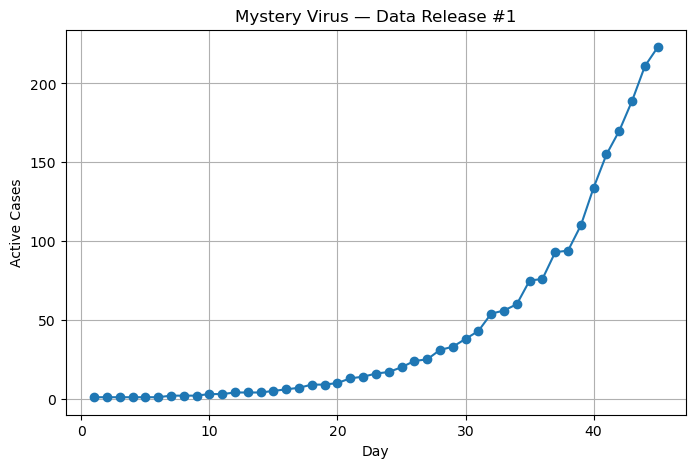

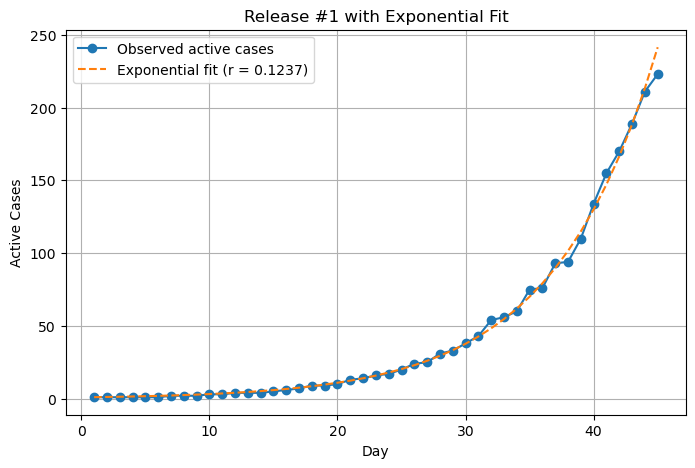

Growth rate r = 0.12372608721883706
Doubling time = 5.602271890599439 days


In [2]:
# Helper Functions
#==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# loads day values and active-case values from a CSV file
def load_active_case_data(filename):
    data = pd.read_csv(filename)

    clean_data = pd.DataFrame({
        "day": pd.to_numeric(data.iloc[:, 0], errors="coerce"),
        "active_cases": pd.to_numeric(data.iloc[:, 2], errors="coerce")
    }).dropna()

    # arrays to be used in the model and plots
    days = clean_data["day"].to_numpy(dtype=float)
    active_cases = clean_data["active_cases"].to_numpy(dtype=float)

    return days, active_cases, data

def calculate_sse(observed, predicted):
    return np.sum((observed - predicted) ** 2)

# SEIR model using Euler's Method
def seir_model(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    # starting values
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    for n in range(len(timepoints) - 1):
        dSdt = -beta * S[n] * I[n] / N
        dEdt = beta * S[n] * I[n] / N - sigma * E[n]
        dIdt = sigma * E[n] - gamma * I[n]
        dRdt = gamma * I[n]

        S[n + 1] = S[n] + dSdt * dt
        E[n + 1] = E[n] + dEdt * dt
        I[n + 1] = I[n] + dIdt * dt
        R[n + 1] = R[n] + dRdt * dt

    return S, E, I, R


# Data Release #1
# ================================

days1, active1, raw1 = load_active_case_data("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 2\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#1.csv")

plt.figure(figsize=(8, 5))
plt.plot(days1, active1, marker="o")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("Mystery Virus — Data Release #1")
plt.grid(True)
plt.show()

fit_days = days1[19:]
fit_cases = active1[19:]

# This finds the exponential growth rate from the log-transformed data
coeffs = np.polyfit(fit_days, np.log(fit_cases), 1)
r, log_a = coeffs
a = np.exp(log_a)
fit_line = a * np.exp(r * days1)

plt.figure(figsize=(8, 5))
plt.plot(days1, active1, "o-", label="Observed active cases")
plt.plot(days1, fit_line, "--", label=f"Exponential fit (r = {r:.4f})")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("Release #1 with Exponential Fit")
plt.legend()
plt.grid(True)
plt.show()

doubling_time = np.log(2) / r
print("Growth rate r =", r)
print("Doubling time =", doubling_time, "days")

### **DATA RELEASE #2**

#### **2c. Use Euler's method to solve the SEIR model.**
This section should come from your python code after Data Release #2.

In [3]:
# Data Release #2
# ================================

days2, active2, raw2 = load_active_case_data("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 2\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#2.csv")

print("First few rows of Release #2:")
print(raw2.head())

print("\nNumber of usable data points:", len(days2))
print("First few days:", days2[:5])
print("First few active-case values:", active2[:5])

First few rows of Release #2:
   day        date  active reported daily cases
0    1  2026-03-01                            1
1    2  2026-03-02                            1
2    3  2026-03-03                            1
3    4  2026-03-04                            1
4    5  2026-03-05                            1

Number of usable data points: 70
First few days: [1. 2. 3. 4. 5.]
First few active-case values: [1. 1. 1. 1. 1.]


#### **2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.**

Initial parameter guess results:
beta = 0.4
sigma = 0.25
gamma = 0.1
SSE = 11921900.519107016
Peak predicted active cases = 2912.1236495097614
Peak observed active cases = 2364.0


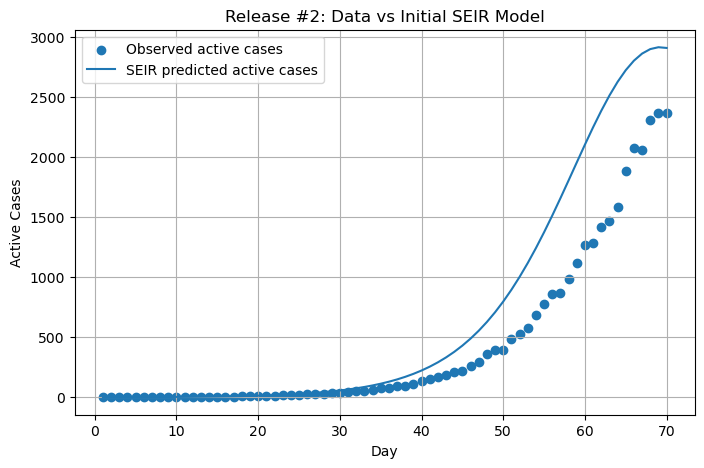

In [4]:
# starting assumptions for  population and compartments
N = 10000
I0 = active2[0]
E0 = I0
R0_initial = 0
S0 = N - E0 - I0 - R0_initial

timepoints2 = days2

# initial parameter guesses before optimization
beta_guess = 0.40
sigma_guess = 0.25
gamma_guess = 0.10

S_guess, E_guess, I_guess, R_guess = seir_model(
    beta_guess, sigma_guess, gamma_guess,
    S0, E0, I0, R0_initial,
    timepoints2, N
)

sse_guess = calculate_sse(active2, I_guess)

print("Initial parameter guess results:")
print("beta =", beta_guess)
print("sigma =", sigma_guess)
print("gamma =", gamma_guess)
print("SSE =", sse_guess)
print("Peak predicted active cases =", np.max(I_guess))
print("Peak observed active cases =", np.max(active2))

plt.figure(figsize=(8, 5))
plt.scatter(days2, active2, label="Observed active cases")
plt.plot(timepoints2, I_guess, label="SEIR predicted active cases")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("Release #2: Data vs Initial SEIR Model")
plt.legend()
plt.grid(True)
plt.show()

#### **2e. Plot the model-predicted infections over time compared to the data.**

Best-fit parameters:
Best beta = 0.3615384615384616
Best sigma = 0.21588235294117647
Best gamma = 0.09
Best E0 = 1.0
Lowest SSE = 70692.92505980722
Peak predicted active cases = 2447.2806441986527
Peak observed active cases = 2364.0


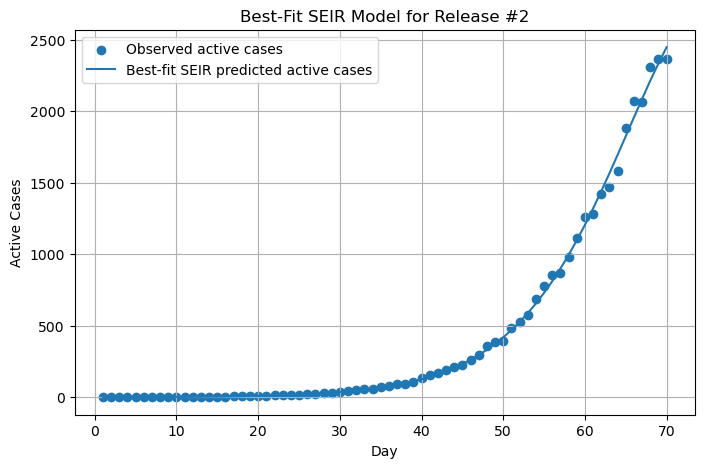

Model interpretation:
Estimated R0 = 4.017094017094018
Estimated latent period (days) = 4.632152588555859
Estimated infectious period (days) = 11.11111111111111


In [5]:
# Data Release #2 — Grid Search Optimization
# ================================

beta_vals = np.linspace(0.15, 0.90, 40)
sigma_vals = np.linspace(0.08, 0.50, 35)
gamma_vals = np.linspace(0.03, 0.20, 35)
E0_multipliers = [1, 1.5, 2, 3, 4]

# These variables keep track of the best fit found so far
best_sse = np.inf
best_beta = None
best_sigma = None
best_gamma = None
best_E0 = None
best_I = None

for E_mult in E0_multipliers:
    E0_try = E_mult * I0
    S0_try = N - E0_try - I0 - R0_initial

    for beta in beta_vals:
        for sigma in sigma_vals:
            for gamma in gamma_vals:
                S_try, E_try, I_try, R_try = seir_model(
                    beta, sigma, gamma,
                    S0_try, E0_try, I0, R0_initial,
                    timepoints2, N
                )

                sse = calculate_sse(active2, I_try)

                if sse < best_sse:
                    best_sse = sse
                    best_beta = beta
                    best_sigma = sigma
                    best_gamma = gamma
                    best_E0 = E0_try
                    best_I = I_try

print("Best-fit parameters:")
print("Best beta =", best_beta)
print("Best sigma =", best_sigma)
print("Best gamma =", best_gamma)
print("Best E0 =", best_E0)
print("Lowest SSE =", best_sse)
print("Peak predicted active cases =", np.max(best_I))
print("Peak observed active cases =", np.max(active2))

plt.figure(figsize=(8, 5))
plt.scatter(days2, active2, label="Observed active cases")
plt.plot(timepoints2, best_I, label="Best-fit SEIR predicted active cases")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("Best-Fit SEIR Model for Release #2")
plt.legend()
plt.grid(True)
plt.show()

# These values help interpret the meaning of the best-fit parameters
R0_model = best_beta / best_gamma
latent_period = 1 / best_sigma
infectious_period = 1 / best_gamma

print("Model interpretation:")
print("Estimated R0 =", R0_model)
print("Estimated latent period (days) =", latent_period)
print("Estimated infectious period (days) =", infectious_period)

#### **2e. Prediction: day and amount of active cases at the peak of the epidemic spread.**


Future outbreak prediction:
Predicted peak day = 77
Predicted peak active cases = 2872.629840236025


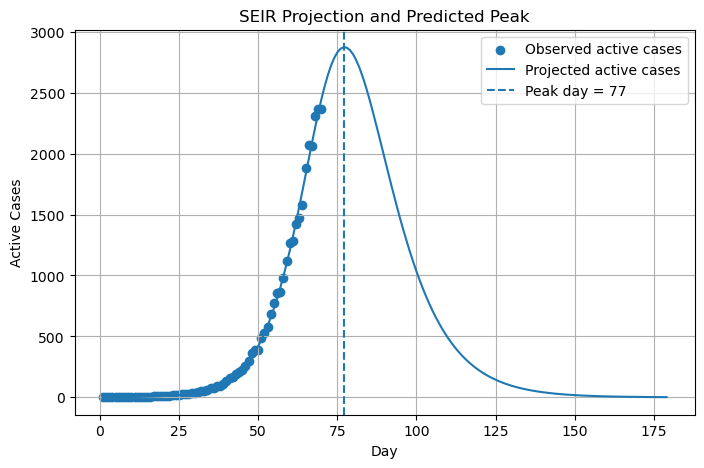

In [6]:
# This rebuilds the starting susceptible population using the best E0 value
S0_best = N - best_E0 - I0 - R0_initial

future_timepoints = np.arange(1, 180, 1)

S_future, E_future, I_future, R_future = seir_model(
    best_beta, best_sigma, best_gamma,
    S0_best, best_E0, I0, R0_initial,
    future_timepoints, N
)

# This finds the predicted peak from the future simulation
peak_index = np.argmax(I_future)
peak_day = future_timepoints[peak_index]
peak_value = I_future[peak_index]

print("Future outbreak prediction:")
print("Predicted peak day =", peak_day)
print("Predicted peak active cases =", peak_value)

# This plots the future prediction and marks the predicted peak day
plt.figure(figsize=(8, 5))
plt.scatter(days2, active2, label="Observed active cases")
plt.plot(future_timepoints, I_future, label="Projected active cases")
plt.axvline(peak_day, linestyle="--", label=f"Peak day = {peak_day}")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("SEIR Projection and Predicted Peak")
plt.legend()
plt.grid(True)
plt.show()

### **DATA RELEASE #3**

#### **2f. Plot the full dataset (Data Release #3) against prediction**

First few rows of Release #3:
   day        date  active reported daily cases
0    1  2026-03-01                            1
1    2  2026-03-02                            1
2    3  2026-03-03                            1
3    4  2026-03-04                            1
4    5  2026-03-05                            1

Number of usable data points: 120
First few days: [1. 2. 3. 4. 5.]
First few active-case values: [1. 1. 1. 1. 1.]


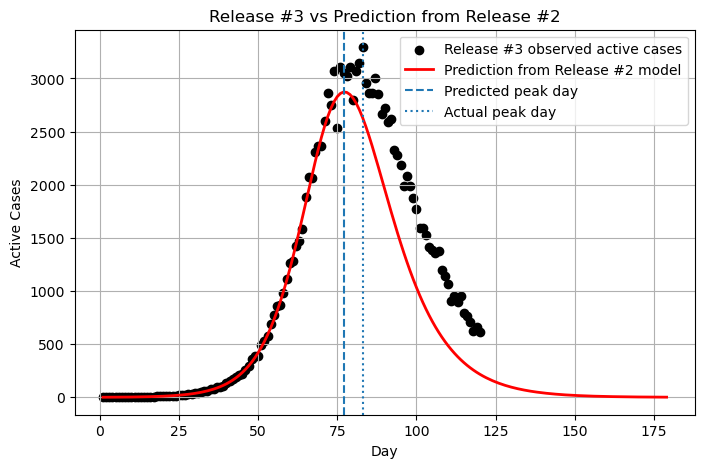

Actual peak from Release #3:
Actual peak day = 83.0
Actual peak active cases = 3294.0

Relative errors:
Relative error in peak active cases = 12.792050994656199 %
Relative error in peak day = 7.228915662650602 %


In [7]:
# Data Release #3
# ================================

# This loads the third release of active-case data
days3, active3, raw3 = load_active_case_data("C:\\Users\\15712\\OneDrive - University of Virginia\\Comp Mod 2\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#3.csv")

# These print statements help verify the data
print("First few rows of Release #3:")
print(raw3.head())

print("\nNumber of usable data points:", len(days3))
print("First few days:", days3[:5])
print("First few active-case values:", active3[:5])

# This finds the actual peak in Release #3
actual_peak_index = np.argmax(active3)
actual_peak_day = days3[actual_peak_index]
actual_peak_value = active3[actual_peak_index]

# This plots the Release #3 data against the prediction made from Release #2
plt.figure(figsize=(8, 5))
plt.scatter(days3, active3, color="black", label="Release #3 observed active cases")
plt.plot(future_timepoints, I_future, color="red", linewidth=2, label="Prediction from Release #2 model")
plt.axvline(peak_day, linestyle="--", label="Predicted peak day")
plt.axvline(actual_peak_day, linestyle=":", label="Actual peak day")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("Release #3 vs Prediction from Release #2")
plt.legend()
plt.grid(True)
plt.show()

# This prints the actual peak values from Release #3
print("Actual peak from Release #3:")
print("Actual peak day =", actual_peak_day)
print("Actual peak active cases =", actual_peak_value)

# These calculate the relative errors in peak size and peak timing
error_y = abs(peak_value - actual_peak_value) / actual_peak_value * 100
error_x = abs(peak_day - actual_peak_day) / actual_peak_day * 100

print("\nRelative errors:")
print("Relative error in peak active cases =", error_y, "%")
print("Relative error in peak day =", error_x, "%")

##### Data Release #3 Curve of Best Fit

Gaussian fit parameters:
Peak height = 3032.129757570131
Peak day = 82.78171806925087
Spread parameter = 17.635795610861944


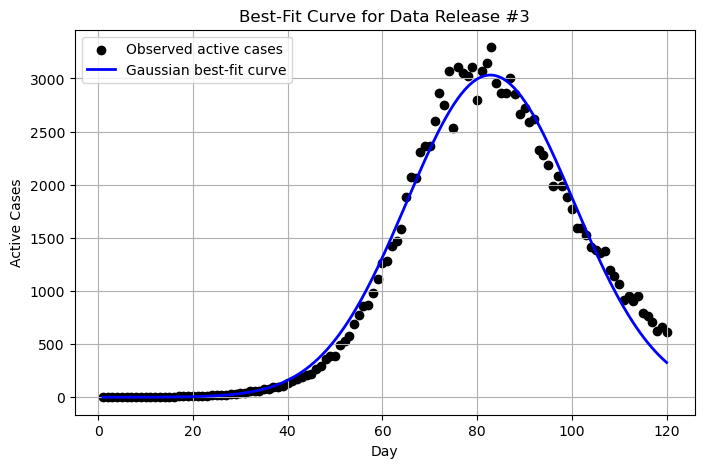

In [8]:
# Data Release #3 — Curve of Best Fit
# ================================

from scipy.optimize import curve_fit

# This defines a Gaussian function to model the epidemic curve
def gaussian(x, a, b, c):
    return a * np.exp(-((x - b)**2) / (2 * c**2))

# Initial guesses for the Gaussian parameters
a_guess = np.max(active3)
b_guess = days3[np.argmax(active3)]
c_guess = 15

initial_guess = [a_guess, b_guess, c_guess]

# Fit the Gaussian model to the Release #3 data
params, covariance = curve_fit(gaussian, days3, active3, p0=initial_guess)

a_fit, b_fit, c_fit = params

print("Gaussian fit parameters:")
print("Peak height =", a_fit)
print("Peak day =", b_fit)
print("Spread parameter =", c_fit)

# Generate smooth curve for plotting
smooth_days = np.linspace(min(days3), max(days3), 300)
gaussian_fit = gaussian(smooth_days, a_fit, b_fit, c_fit)

# Plot the observed data and Gaussian best fit
plt.figure(figsize=(8,5))

plt.scatter(days3, active3, color="black", label="Observed active cases")
plt.plot(smooth_days, gaussian_fit, color="blue", linewidth=2, label="Gaussian best-fit curve")

plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("Best-Fit Curve for Data Release #3")
plt.legend()
plt.grid(True)

plt.show()

#### **2g. Intervention strategies for new outbreak at VT (70 days of infection)**



##### **Mandated Masking Intervention at Day 70**

Best-fit Release #3 parameters:
Best beta = 0.4571428571428572
Best sigma = 0.1
Best gamma = 0.07142857142857142
Best E0 = 3.0
Lowest SSE = 679200.0376038344


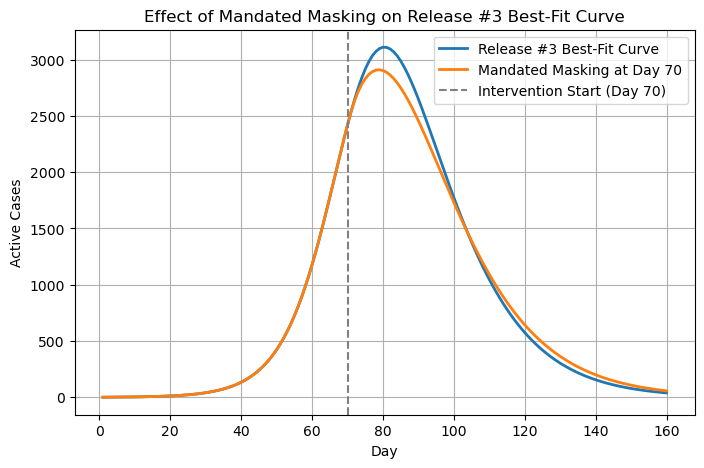

In [ ]:
# Mandated Masking Intervention at Day 70
# ================================================================

# This creates a best-fit SEIR model using Release #3 data
beta_vals_3 = np.linspace(0.2, 0.8, 15)
sigma_vals_3 = np.linspace(0.1, 0.4, 15)
gamma_vals_3 = np.linspace(0.04, 0.15, 15)
E0_multipliers_3 = [1, 2, 3]

# These variables store the best Release #3 fit
best_sse_3 = np.inf
best_beta_3 = None
best_sigma_3 = None
best_gamma_3 = None
best_E0_3 = None
best_I_3 = None

# These are the initial conditions based on Release #3
I0_3 = active3[0]
R0_3 = 0
N_3 = N

# This searches for the best-fit SEIR curve for Release #3
for E_mult in E0_multipliers_3:
    E0_try_3 = E_mult * I0_3
    S0_try_3 = N_3 - E0_try_3 - I0_3 - R0_3

    for beta in beta_vals_3:
        for sigma in sigma_vals_3:
            for gamma in gamma_vals_3:
                S_try_3, E_try_3, I_try_3, R_try_3 = seir_model(
                    beta, sigma, gamma,
                    S0_try_3, E0_try_3, I0_3, R0_3,
                    days3, N_3
                )

                sse_3 = calculate_sse(active3, I_try_3)

                if sse_3 < best_sse_3:
                    best_sse_3 = sse_3
                    best_beta_3 = beta
                    best_sigma_3 = sigma
                    best_gamma_3 = gamma
                    best_E0_3 = E0_try_3
                    best_I_3 = I_try_3

# This prints the best-fit Release #3 model parameters
print("Best-fit Release #3 parameters:")
print("Best beta =", best_beta_3)
print("Best sigma =", best_sigma_3)
print("Best gamma =", best_gamma_3)
print("Best E0 =", best_E0_3)
print("Lowest SSE =", best_sse_3)

# This rebuilds the starting susceptible population for the Release #3 model
S0_best_3 = N_3 - best_E0_3 - I0_3 - R0_3

# This creates a longer time range so the intervention curve can be seen clearly
future_timepoints_3 = np.arange(1, 161, 1)

# This generates the original best-fit Release #3 model with no intervention
S_base_3, E_base_3, I_base_3, R_base_3 = seir_model(
    best_beta_3, best_sigma_3, best_gamma_3,
    S0_best_3, best_E0_3, I0_3, R0_3,
    future_timepoints_3, N_3
)

# Masking reduces transmission by 40 percent, so beta becomes 60 percent of its original value
beta_mask_3 = 0.6 * best_beta_3

# This function applies masking starting at day 70
def seir_with_masking(beta_before, beta_after, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    # This updates the model one day at a time and switches beta at day 70
    for n in range(len(timepoints) - 1):
        if timepoints[n] >= 70:
            beta_current = beta_after
        else:
            beta_current = beta_before

        dSdt = -beta_current * S[n] * I[n] / N
        dEdt = beta_current * S[n] * I[n] / N - sigma * E[n]
        dIdt = sigma * E[n] - gamma * I[n]
        dRdt = gamma * I[n]

        S[n + 1] = S[n] + dSdt * dt
        E[n + 1] = E[n] + dEdt * dt
        I[n + 1] = I[n] + dIdt * dt
        R[n + 1] = R[n] + dRdt * dt

    return S, E, I, R

# This generates the masking intervention curve based on the Release #3 best-fit model
S_mask_3, E_mask_3, I_mask_3, R_mask_3 = seir_with_masking(
    best_beta_3, beta_mask_3, best_sigma_3, best_gamma_3,
    S0_best_3, best_E0_3, I0_3, R0_3,
    future_timepoints_3, N_3
)

# This plots the Release #3 best-fit curve and the masking intervention curve
plt.figure(figsize=(8, 5))

plt.plot(future_timepoints_3, I_base_3, linewidth=2, label="Release #3 Best-Fit Curve")
plt.plot(future_timepoints_3, I_mask_3, linewidth=2, label="Mandated Masking at Day 70")
plt.axvline(70, linestyle="--", color="gray", label="Intervention Start (Day 70)")

plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("Effect of Mandated Masking on Release #3 Best-Fit Curve")
plt.legend()
plt.grid(True)
plt.show()

Mandated Masking

Mandated masking affects the transmission rate parameter, beta, because masks reduce how easily the virus spreads from infected individuals to susceptible individuals. In this intervention, masking was assumed to begin on day 70 and reduce transmission by 40%, so the new transmission rate became 0.6 × beta after that point.

To show this effect, a best-fit SEIR curve was first created using Data Release #3. Then, the masking intervention was applied to that same fitted model beginning on day 70. Compared to the original best-fit curve, the masking curve should show a lower peak and fewer active cases after the intervention begins, demonstrating how reducing transmission can slow the outbreak and reduce its overall severity.

##### **Vaccine Campaign on Day 70**

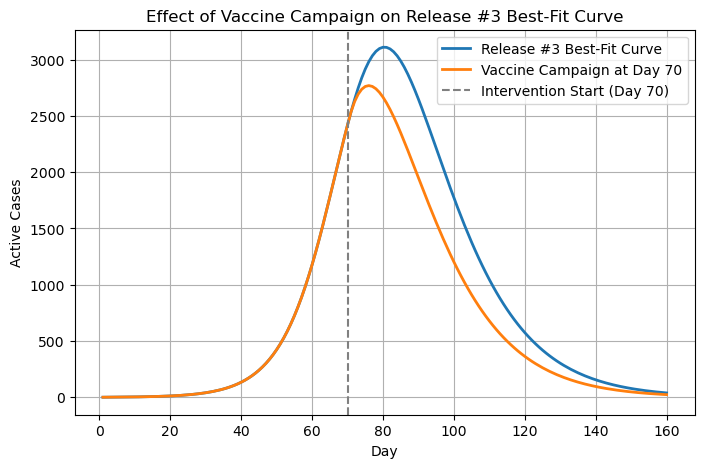

In [10]:
# Vaccine Campaign Intervention
# ================================================================

# This vaccine campaign moves vaccinated susceptible people into the recovered group on day 70
vaccinated_students = 2000
vaccine_efficacy = 0.90
effective_vaccinated = vaccinated_students * vaccine_efficacy

# This function applies a one-time vaccination event on day 70
def seir_with_vaccination(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    vaccination_applied = False

    # This updates the model one step at a time and applies vaccination once at day 70
    for n in range(len(timepoints) - 1):
        dSdt = -beta * S[n] * I[n] / N
        dEdt = beta * S[n] * I[n] / N - sigma * E[n]
        dIdt = sigma * E[n] - gamma * I[n]
        dRdt = gamma * I[n]

        S[n + 1] = S[n] + dSdt * dt
        E[n + 1] = E[n] + dEdt * dt
        I[n + 1] = I[n] + dIdt * dt
        R[n + 1] = R[n] + dRdt * dt

        # This applies the vaccine campaign one time on day 70
        if timepoints[n + 1] >= 70 and not vaccination_applied:
            vaccinated_now = min(effective_vaccinated, S[n + 1])
            S[n + 1] = S[n + 1] - vaccinated_now
            R[n + 1] = R[n + 1] + vaccinated_now
            vaccination_applied = True

    return S, E, I, R

# This generates the vaccine intervention curve based on the Release #3 best-fit model
S_vax_3, E_vax_3, I_vax_3, R_vax_3 = seir_with_vaccination(
    best_beta_3, best_sigma_3, best_gamma_3,
    S0_best_3, best_E0_3, I0_3, R0_3,
    future_timepoints_3, N_3
)

# This plots the Release #3 best-fit curve and the vaccine intervention curve
plt.figure(figsize=(8, 5))

plt.plot(future_timepoints_3, I_base_3, linewidth=2, label="Release #3 Best-Fit Curve")
plt.plot(future_timepoints_3, I_vax_3, linewidth=2, label="Vaccine Campaign at Day 70")
plt.axvline(70, linestyle="--", color="gray", label="Intervention Start (Day 70)")

plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("Effect of Vaccine Campaign on Release #3 Best-Fit Curve")
plt.legend()
plt.grid(True)
plt.show()

Vaccine Campaign

The vaccine campaign affects the susceptible (S) and recovered (R) populations. Because vaccination protects people from becoming infected, it removes individuals from the susceptible group and places them into the recovered/immune group.

In this intervention, 2000 students were vaccinated on day 70 with 90% efficacy, meaning that 1800 students were effectively immunized. In the model, this was implemented as a one-time event that moved 1800 individuals from S to R on day 70.

Compared to the original best-fit curve from Data Release #3, the vaccine intervention should produce a lower epidemic peak and fewer active cases after day 70, because fewer susceptible individuals remain available for the virus to infect.

##### **Two Week School Closure on Day 70**

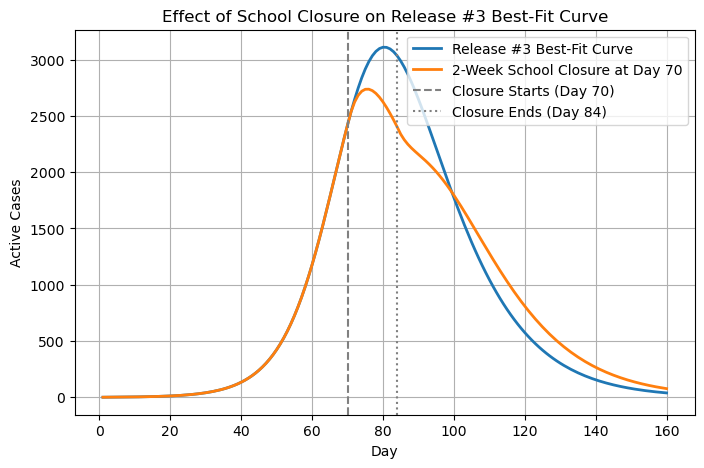

In [11]:
# School Closure Intervention
# ===============================================================

# School closure reduces contact rate to 20 percent of normal for 2 weeks
beta_closure = 0.2 * best_beta_3

# This function applies a temporary school closure from day 70 to day 83
def seir_with_school_closure(beta_before, beta_during, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    # This updates the model one day at a time and changes beta only during the closure period
    for n in range(len(timepoints) - 1):
        if 70 <= timepoints[n] < 84:
            beta_current = beta_during
        else:
            beta_current = beta_before

        dSdt = -beta_current * S[n] * I[n] / N
        dEdt = beta_current * S[n] * I[n] / N - sigma * E[n]
        dIdt = sigma * E[n] - gamma * I[n]
        dRdt = gamma * I[n]

        S[n + 1] = S[n] + dSdt * dt
        E[n + 1] = E[n] + dEdt * dt
        I[n + 1] = I[n] + dIdt * dt
        R[n + 1] = R[n] + dRdt * dt

    return S, E, I, R

# This generates the school closure intervention curve based on the Release #3 best-fit model
S_close_3, E_close_3, I_close_3, R_close_3 = seir_with_school_closure(
    best_beta_3, beta_closure, best_sigma_3, best_gamma_3,
    S0_best_3, best_E0_3, I0_3, R0_3,
    future_timepoints_3, N_3
)

# This plots the Release #3 best-fit curve and the school closure intervention curve
plt.figure(figsize=(8, 5))

plt.plot(future_timepoints_3, I_base_3, linewidth=2, label="Release #3 Best-Fit Curve")
plt.plot(future_timepoints_3, I_close_3, linewidth=2, label="2-Week School Closure at Day 70")
plt.axvline(70, linestyle="--", color="gray", label="Closure Starts (Day 70)")
plt.axvline(84, linestyle=":", color="gray", label="Closure Ends (Day 84)")

plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("Effect of School Closure on Release #3 Best-Fit Curve")
plt.legend()
plt.grid(True)
plt.show()

Two-Week School Closure

The school closure intervention affects the transmission rate parameter, beta, because closing school reduces the number of contacts students have with one another. In this scenario, the school closes on day 70 and remains closed for two weeks. During that time, students experience only 20% of their normal contacts, so the transmission rate is reduced to 0.2 × beta.

In the model, this lower transmission rate was applied from day 70 through day 83. After the closure ended, the transmission rate returned to its original best-fit value. Compared to the original best-fit curve from Data Release #3, this intervention should show a temporary slowing of the outbreak, usually resulting in a lower number of active cases during and shortly after the closure period. Once the school reopens, cases may rise again, but the closure can still delay and reduce the peak.


## **3) Verify and validate your analysis:**

Looking at our data, with our R0 value being about 1.87, we know that interventions strategies can generally slow both the growth rate of thi virus. This is true becaase 1.87 is not the most aggressive R0 values, with some viruses reaching values higher than 10 (Delemater, 2019). The study also goes on to mention that vaccinations is a highly effective method to reduce the R0 coefficient for these viruses, which is something we saw within our own data. Also, our predicted peak day (73rd day) wasn't far off from the actual value (78th day). This time table is mainly due to the infectious period lasting 5-9 days. For viruses that have longer infectious periods like Ebola (7-12 days), you generally see much more agressive spreading, which was the case for Ebola (Ebola: Overview, History, Origins and Transmission, 2025). This implies that the rate our virus spreads, and subsequently the R0 value, correspond with the data we reviewed.

## **4) Conclusions and Ethical Implications:**

Since the model is an exponential curve, the number of infections takes its time to grow, but as days pass the disease spreads at alarming rates. The best way to measure this spread is through the R0 value, which tells us how many people are infected by one person, which helps determine how contagious a disease is. Knowing this could help us predict the rate of spread, and it also influenced our intervention strategies for VT's outbreak. Respiratory particles can spread fast, but wearing a mask is s trong way yto counter this, and hence why it was one of the stronger intervention strategies.
However, airborne pathogens spread at faster rates than respiratory droplets, which would result in a steeper curve. Our flatter curve allows for these intervention strategies to come into effect while the number of active cases is lower, which makes it better for all parties involved. Our R0 value was approximately 1.87, and another virus that has a similar R0 value is Ebola, with an R0 value of ~2. Ebola is caused by the Ebola virus, and symptoms can appear up to 15 days after exposure in extreme cases. The one difference is Ebola spreads through contact rather than respiratory droplets, which could potentially indicate that Ebola may not be our unkown disease. 

## **5) Limitations and Future Work:**

***Limitations***

This analysis is subject to several important limitations that stem from both the structure of the SEIR model and the assumptions made during implementation. First, the model assumes homogeneous mixing within the population, meaning that every individual has an equal probability of interacting with every other individual. In reality, the UVA population is highly structured, with interactions influenced by housing, classes, athletic teams, and social groups. This simplification may lead to inaccuracies in predicting how quickly or widely the disease spreads.

Additionally, the parameter values used in the model—specifically the transmission rate (β), incubation rate (σ), and recovery rate (γ)—were estimated from limited data and assumed to remain constant over time. In real-world scenarios, these parameters are dynamic and influenced by behavioral changes, policy interventions, and environmental factors. As a result, the model may not fully capture shifts in transmission patterns over the course of the outbreak.

Another limitation is the assumption of a closed and constant population. The model does not account for individuals entering or leaving the system, such as students traveling, isolating, or interacting with individuals outside the UVA community. Furthermore, the intervention strategies were implemented as immediate and uniformly effective changes, which likely overestimates their real-world impact. For example, masking compliance and vaccine uptake are rarely instantaneous or universal.

Finally, the analysis relies on reported active case data, which may underestimate the true number of infections due to asymptomatic cases, testing limitations, or reporting delays. This introduces uncertainty into both the parameter estimation process and the evaluation of model accuracy.


***Future Work***

Future work could focus on improving the realism and predictive power of the model by addressing these limitations. One key improvement would be incorporating heterogeneous mixing by dividing the population into subgroups based on living situations, academic schedules, or social behavior. This would allow the model to better reflect how diseases spread through specific networks rather than uniformly across the entire population.

Another important extension would be the use of time-varying parameters. Allowing the transmission, incubation, and recovery rates to change over time would enable the model to capture the effects of evolving behaviors, policy changes, and seasonal trends. This could significantly improve the model’s ability to match real-world data and make more accurate predictions.

Future models could also incorporate stochastic elements to account for randomness in disease transmission. Unlike deterministic models, stochastic approaches can better represent variability in individual interactions and outcomes, especially in smaller populations or early outbreak stages.

In terms of interventions, future analyses could model more realistic implementation strategies, such as gradual vaccine rollouts, partial compliance with masking, or delayed policy effects. This would provide a more accurate assessment of how interventions influence disease dynamics over time. Additionally, integrating real-world epidemiological or campus-specific data could strengthen model validation and improve confidence in the results.

Finally, expanding the scope of the model to include economic or operational impacts—such as the cost of school closures or disruptions to campus life—could provide a more comprehensive framework for decision-making. This would allow stakeholders to better evaluate the trade-offs between public health outcomes and practical constraints.

## **Citations**
Delamater, P. L., Street, E. J., Leslie, T. F., Yang, Y. T., & Jacobsen, K. H. (2019). Complexity of the Basic Reproduction Number (R0). Emerging infectious diseases, 25(1), 1–4. https://doi.org/10.3201/eid2501.171901

Ebola: overview, history, origins and transmission. (2025, September 4). GOV.UK. https://www.gov.uk/government/publications/ebola-origins-reservoirs-transmission-and-guidelines/ebola-overview-history-origins-and-transmission#contents